# Week 4 | The EDA book

**Employee Attrition Evidence Lab · Batch 3 / Team 3**

This book explores the supplied employee records and distinguishes repeatable associations
from weak claims. Read it as **context → comparisons → evidence checks → interpretation**.
Every result is calculated from the replacement dataset. The previous presentation's model
scores are placeholders and are not reused.

**Questions:** How are the numeric and categorical fields distributed? Which groups have
higher left shares? Do the differences survive cleaning choices and role comparisons?

All intervals are exploratory 95% intervals assuming independent observations. Unknown
sampling, synthetic provenance or clustering can invalidate population interpretations.
Multiple exploratory comparisons are not confirmatory hypothesis tests; there is no
claim of family-wise statistical significance.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Works when opened from the notebook folder, DSV_PROJECT, or repository root.
ROOT = next((p if (p/'Source_Code'/'attrition_lab.py').exists() else p/'DSV_PROJECT'
             for p in [Path.cwd(), *Path.cwd().parents]
             if (p/'Source_Code'/'attrition_lab.py').exists()
             or (p/'DSV_PROJECT'/'Source_Code'/'attrition_lab.py').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Open this notebook inside the DSV_PROJECT workspace.')
sys.path.insert(0, str(ROOT/'Source_Code'))
from attrition_lab import (load_raw, clean_data, quality_report, outlier_report,
                          rate_table, compare, evidence_tables, scenarios,
                          build_artifacts, NUMERIC, MISSING, ORDERS, CONTRASTS)
raw = load_raw()
sns.set_theme(style='whitegrid', palette=['#176B87','#DA7652','#71AFA0','#A18CB8'])
plt.rcParams.update({'figure.dpi':110, 'axes.spines.top':False, 'axes.spines.right':False,
                     'axes.titleweight':'bold', 'axes.titlesize':13, 'font.size':10})
FIGURES = ROOT/'Reports'/'Figures'
FIGURES.mkdir(parents=True, exist_ok=True)
def finish(name):
    plt.tight_layout()
    plt.savefig(FIGURES/f'{name}.png', dpi=145, bbox_inches='tight')
    plt.show()
    plt.close()
pd.set_option('display.max_columns', 12)

After exact deduplication: **74,498 records**, **35,370 Left**, **39,128 Stayed**. Observed left share: **47.48%**. This is not an annual turnover rate.

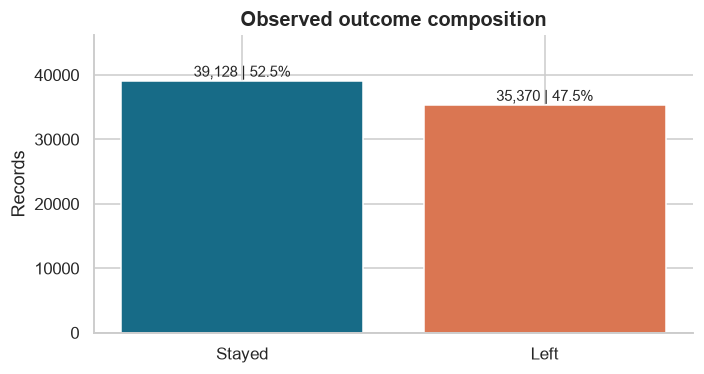

In [2]:
clean = clean_data(raw)
build_artifacts()
n = len(clean); left = int(clean.Left.sum())
display(Markdown(f'After exact deduplication: **{n:,} records**, **{left:,} Left**, '
                 f'**{n-left:,} Stayed**. Observed left share: **{left/n:.2%}**. '
                 'This is not an annual turnover rate.'))
fig,ax = plt.subplots(figsize=(6.5,3.5))
counts = clean['Attrition'].value_counts().reindex(['Stayed','Left'])
ax.bar(counts.index,counts.values,color=['#176B87','#DA7652'])
for i,v in enumerate(counts): ax.text(i,v+600,f'{v:,} | {v/n:.1%}',ha='center')
ax.set_ylim(0,counts.max()*1.18); ax.set_ylabel('Records'); ax.set_title('Observed outcome composition')
finish('04_outcome_composition')

## 1. Numeric distributions and descriptive statistics

Mean, median, spread, skewness and **excess** kurtosis describe different aspects of shape.
An extreme income can shift the mean while barely moving the median. Tenure-related plots
are diagnostics because their definitions are unresolved. No ID column enters a correlation.

,count,mean,std,min,25%,50%,75%,max,median,variance,skewness,excess_kurtosis
Age,74498.0,38.53,12.08,18.0,28.0,39.0,49.0,59.0,39.0,146.01,-0.00,-1.19
Years at Company,74498.0,15.72,11.22,1.0,7.0,13.0,23.0,51.0,13.0,125.97,0.79,-0.12
Monthly Income,74498.0,7344.88,2597.08,1226.0,5652.0,7348.0,8876.0,50030.0,7348.0,6744846.52,5.21,83.25
Number of Promotions,74498.0,0.83,1.00,0.0,0.0,1.0,2.0,4.0,1.0,0.99,0.99,0.17
Distance from Home,74498.0,49.99,28.15,1.0,26.0,50.0,74.0,99.0,50.0,792.53,0.00,-1.15
Number of Dependents,74498.0,1.66,1.58,0.0,0.0,1.0,3.0,15.0,1.0,2.50,0.92,1.41
Company Tenure (In Months),74498.0,55.72,24.98,2.0,36.0,56.0,75.0,128.0,56.0,624.15,0.07,-0.72


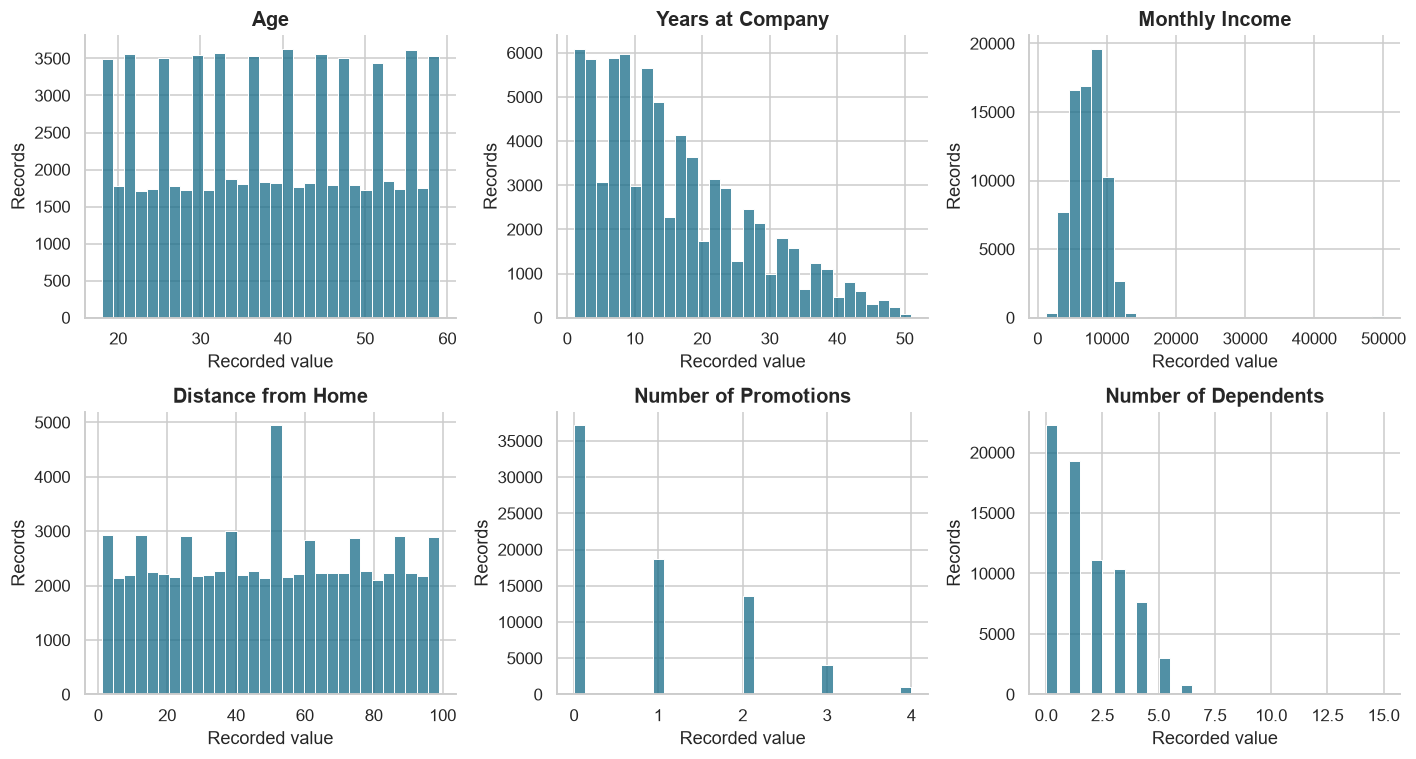

In [3]:
display(pd.read_csv(ROOT/'Reports'/'descriptive_statistics.csv',index_col=0).round(2))
fig,axes = plt.subplots(2,3,figsize=(13,7))
fields = ['Age','Years at Company','Monthly Income','Distance from Home','Number of Promotions','Number of Dependents']
for ax,col in zip(axes.flat,fields):
    sns.histplot(clean[col],bins=30,ax=ax,color='#176B87')
    ax.set_title(col); ax.set_xlabel('Recorded value'); ax.set_ylabel('Records')
finish('04_numeric_distributions')

## 2. Categorical distributions

Counts show representation, not propensity to leave. Ordered categories are kept in their
meaningful order. A large group may contain more departures even when its left share is lower.

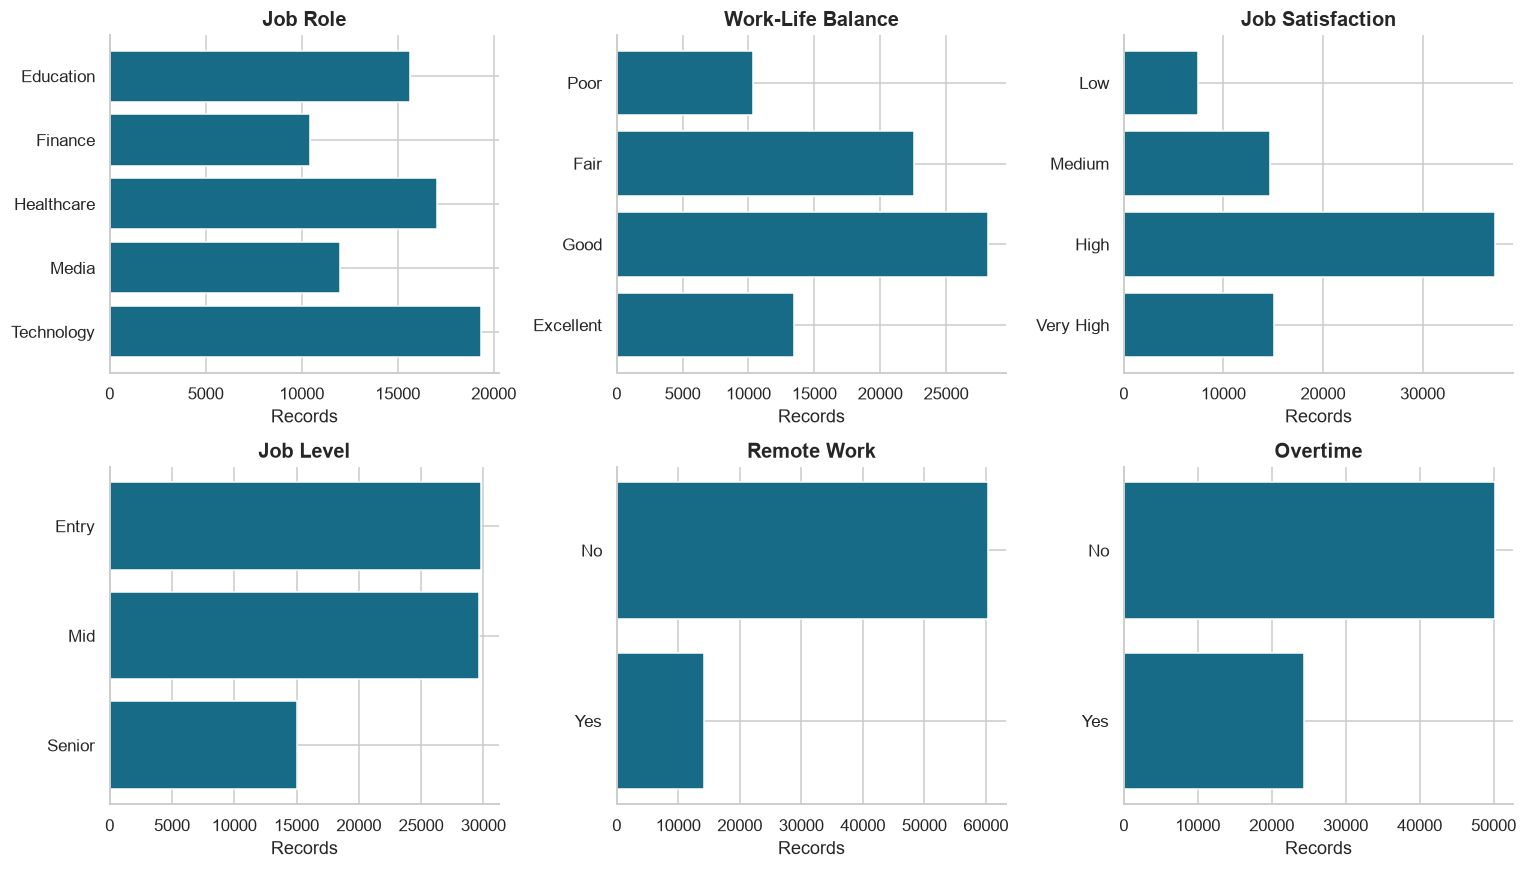

In [4]:
fig,axes = plt.subplots(2,3,figsize=(14,8))
for ax,col in zip(axes.flat,['Job Role','Work-Life Balance','Job Satisfaction','Job Level','Remote Work','Overtime']):
    order = ORDERS.get(col,sorted(clean[col].unique()))
    counts = clean[col].value_counts().reindex(order)
    ax.barh(counts.index,counts.values,color='#176B87'); ax.invert_yaxis()
    ax.set_title(col); ax.set_xlabel('Records')
finish('04_categorical_distributions')

## 3. Outcome comparisons with uncertainty

Each dot below is a group's observed left share. Horizontal bars show Wilson 95% intervals.
Display counts alongside the estimates, and compare rates rather than only departure totals.
The job-satisfaction relationship need not be monotonic: inspect all categories instead of
assuming that every higher rating means lower attrition.

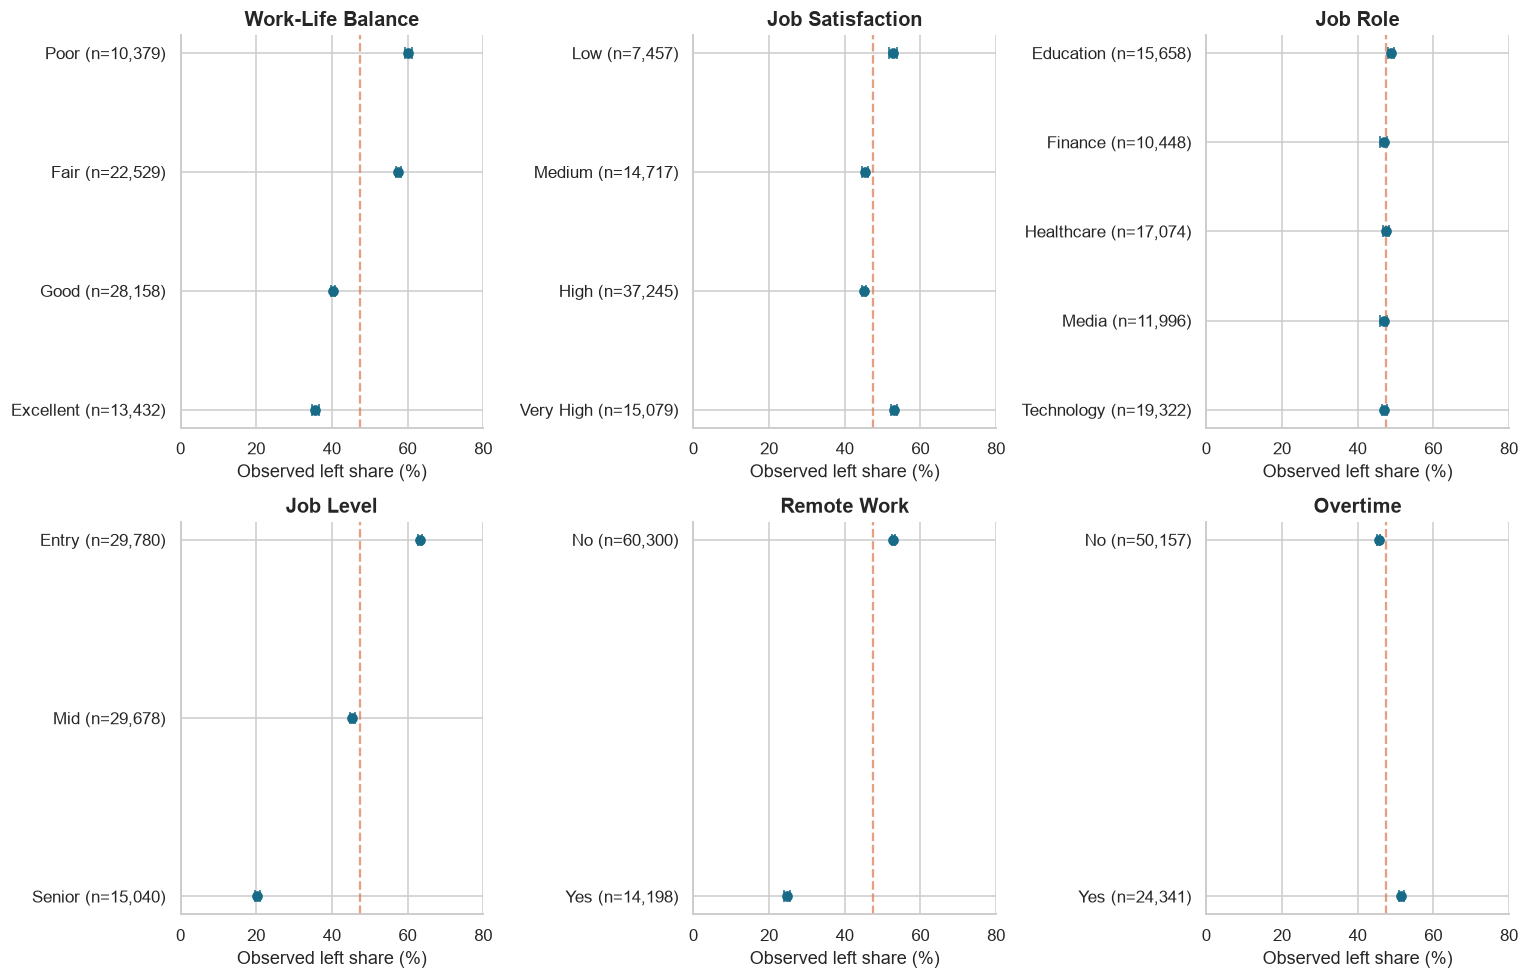

,Job Satisfaction,n,left,left_share_pct,ci_low_pct,ci_high_pct
0,High,37245,16759,45.00,44.49,45.50
1,Low,7457,3936,52.78,51.65,53.91
2,Medium,14717,6679,45.38,44.58,46.19
3,Very High,15079,7996,53.03,52.23,53.82


**Interpretation:** Very High satisfaction is not the lowest-left-share category in this file. This challenges a simple satisfaction story and makes source validation and fuller subgroup analysis important.

In [5]:
fig,axes = plt.subplots(2,3,figsize=(14,9))
for ax,col in zip(axes.flat,['Work-Life Balance','Job Satisfaction','Job Role','Job Level','Remote Work','Overtime']):
    t = rate_table(clean,col)
    order = ORDERS.get(col,sorted(clean[col].unique()))
    t = t.set_index(col).reindex(order).reset_index()
    ax.errorbar(t.left_share_pct,np.arange(len(t)),
                xerr=[t.left_share_pct-t.ci_low_pct,t.ci_high_pct-t.left_share_pct],
                fmt='o',color='#176B87',capsize=4)
    ax.set_yticks(np.arange(len(t)),[f'{v} (n={k:,})' for v,k in zip(t[col],t.n)])
    ax.axvline(clean.Left.mean()*100,color='#DA7652',linestyle='--',alpha=.7)
    ax.set_xlim(0,80); ax.invert_yaxis(); ax.set_xlabel('Observed left share (%)'); ax.set_title(col)
finish('04_group_shares')
display(rate_table(clean,'Job Satisfaction').round(2))
display(Markdown('**Interpretation:** Very High satisfaction is not the lowest-left-share category '
                 'in this file. This challenges a simple satisfaction story and makes source '
                 'validation and fuller subgroup analysis important.'))

## 4. Numeric features by outcome

Boxplots compare medians and spread without assuming normal distributions. We retain tail
points. The violin displays the full observed age distribution by outcome. Overlap between
groups means a group-level association does not identify which individual will leave.

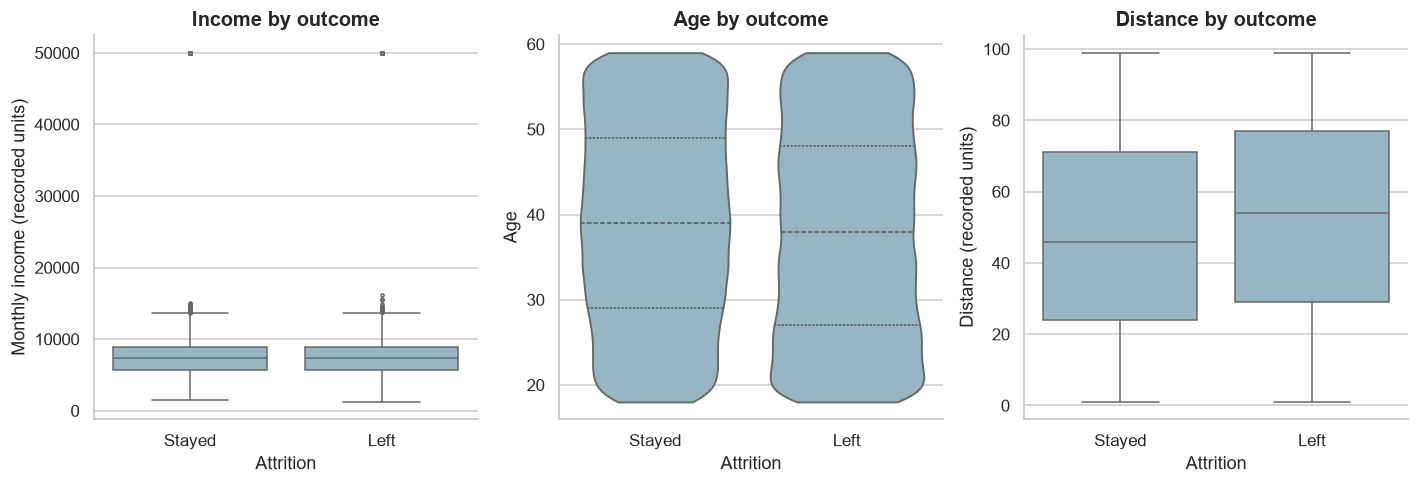

Monthly Income            Age        Distance from Home       
                    mean  median   mean median               mean median
Attrition                                                               
Left             7317.03  7319.0  37.88   38.0              52.74   54.0
Stayed           7370.04  7374.0  39.11   39.0              47.51   46.0

In [6]:
fig,axes = plt.subplots(1,3,figsize=(13,4.5))
sns.boxplot(data=clean,x='Attrition',y='Monthly Income',order=['Stayed','Left'],ax=axes[0],color='#8DBACA',fliersize=2)
axes[0].set_ylabel('Monthly income (recorded units)'); axes[0].set_title('Income by outcome')
sns.violinplot(data=clean,x='Attrition',y='Age',order=['Stayed','Left'],ax=axes[1],color='#8DBACA',inner='quart',cut=0)
axes[1].set_title('Age by outcome')
sns.boxplot(data=clean,x='Attrition',y='Distance from Home',order=['Stayed','Left'],ax=axes[2],color='#8DBACA')
axes[2].set_ylabel('Distance (recorded units)'); axes[2].set_title('Distance by outcome')
finish('04_numeric_by_outcome')
display(clean.groupby('Attrition')[['Monthly Income','Age','Distance from Home']].agg(['mean','median']).round(2))

## 5. Relationships between numeric features

Spearman correlation summarizes monotonic association. It does not imply causation or show
all nonlinear relationships. Company tenure in months is excluded from substantive correlation
because its meaning conflicts with the other tenure field. Age and Years at Company remain
diagnostic only. Binary Left is included solely as an observed outcome indicator.

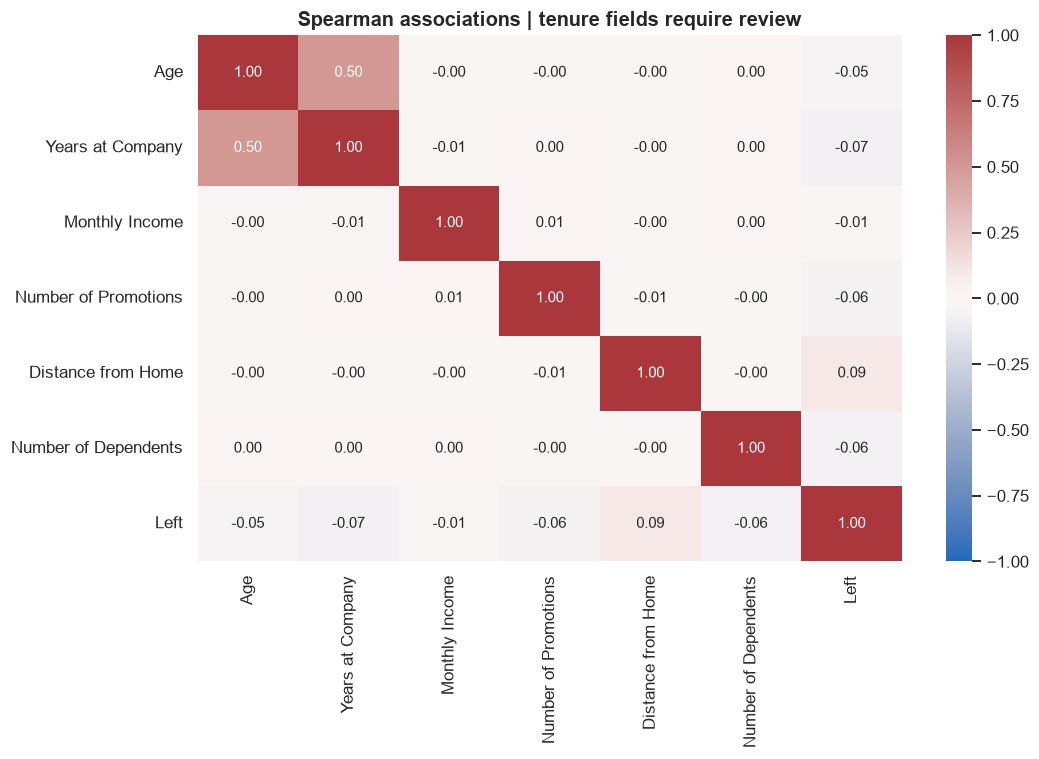

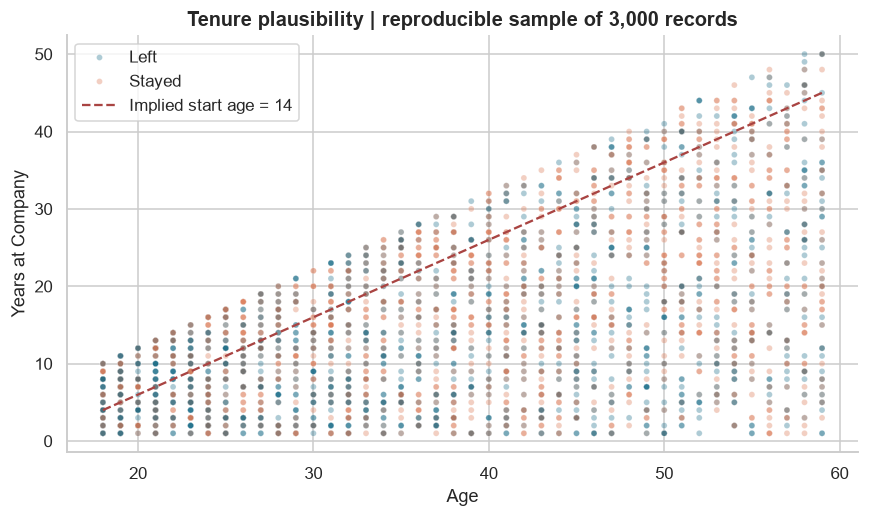

In [7]:
cols = ['Age','Years at Company','Monthly Income','Number of Promotions','Distance from Home','Number of Dependents','Left']
corr = clean[cols].corr(method='spearman')
fig,ax = plt.subplots(figsize=(10,7))
sns.heatmap(corr,annot=True,fmt='.2f',cmap='vlag',vmin=-1,vmax=1,center=0,ax=ax)
ax.set_title('Spearman associations | tenure fields require review')
finish('04_correlation')
sample = clean.sample(min(3000,len(clean)),random_state=42)
fig,ax = plt.subplots(figsize=(8,4.8))
sns.scatterplot(data=sample,x='Age',y='Years at Company',hue='Attrition',alpha=.35,s=15,ax=ax)
x = np.arange(18,60); ax.plot(x,x-14,'--',color='#A94442',label='Implied start age = 14')
ax.legend(); ax.set_title('Tenure plausibility | reproducible sample of 3,000 records')
finish('04_age_tenure_diagnostic')

## 6. Combined exposure: overtime and work-life balance

This extension asks whether overtime differences are present within each balance category.
It is an observed cross-tabulation, not an intervention simulation. Even a large difference
cannot establish that changing overtime will prevent departures.

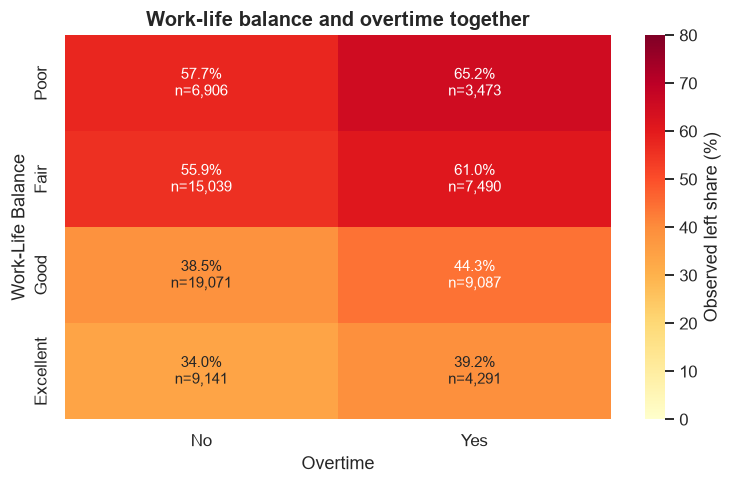

,Work-Life Balance,Overtime,n,left,left_share_pct,ci_low_pct,ci_high_pct
0,Excellent,No,9141,3108,34.00,33.04,34.98
1,Excellent,Yes,4291,1681,39.18,37.72,40.64
2,Fair,No,15039,8400,55.85,55.06,56.65
3,Fair,Yes,7490,4567,60.97,59.86,62.07
4,Good,No,19071,7346,38.52,37.83,39.21
5,Good,Yes,9087,4022,44.26,43.24,45.28
6,Poor,No,6906,3982,57.66,56.49,58.82
7,Poor,Yes,3473,2264,65.19,63.59,66.76


In [8]:
joint = rate_table(clean,['Work-Life Balance','Overtime'])
p = joint.pivot(index='Work-Life Balance',columns='Overtime',values='left_share_pct').reindex(ORDERS['Work-Life Balance'])
ns = joint.pivot(index='Work-Life Balance',columns='Overtime',values='n').reindex(ORDERS['Work-Life Balance'])
labels = p.copy().astype(str)
for row in p.index:
    for col in p.columns: labels.loc[row,col] = f'{p.loc[row,col]:.1f}%\nn={ns.loc[row,col]:,}'
fig,ax = plt.subplots(figsize=(7,4.5))
sns.heatmap(p,annot=labels,fmt='',cmap='YlOrRd',vmin=0,vmax=80,ax=ax,cbar_kws={'label':'Observed left share (%)'})
ax.set_title('Work-life balance and overtime together')
finish('04_balance_overtime')
display(joint.round(2))

## 7. Novelty prototype: evidence attached to each claim

Seven explicitly defined comparisons are screened across five scenarios: global median,
role-level median, complete-case, excluding implied starting ages below 14, and income capping.
The source data remain unchanged. Income capping cannot change purely categorical comparisons;
its identical results are expected and are not independent validation. See Week 3 for its
effect on income summaries. The commute comparison is directly affected by imputation.

**Project thresholds (editable below):** at least 200 records per comparison arm; absolute
difference of at least 5 percentage points in every scenario; a 95% difference interval that
excludes zero in every scenario; same direction across scenarios and all five job roles;
cleaning-induced swing at most 2 percentage points; role-and-level standardized difference
at least 5 percentage points in the same direction, covering at least 90% of records.

These thresholds are transparent design choices, not a validated clinical, legal or business
standard. Comparisons are exploratory and were chosen after inspecting the available fields.
`Robust descriptive signal` means only that the stated checks passed in this supplied file.
It is not a recommendation to act on individual employees.

In [9]:
MIN_GROUP_N = 200
PRACTICAL_DIFFERENCE_PP = 5.0
MAX_CLEANING_SWING_PP = 2.0
scorecard,sensitivity,within_role = evidence_tables(raw,MIN_GROUP_N,PRACTICAL_DIFFERENCE_PP,MAX_CLEANING_SWING_PP)
display(pd.DataFrame([{'comparison':name,'field':c,'exposed':str(e) if e else '>= 50',
                      'reference':str(r) if r else '< 50'} for name,(c,e,r) in CONTRASTS.items()]))
display(scorecard.round(3))

,comparison,field,exposed,reference
0,Overtime,Overtime,['Yes'],['No']
1,Limited remote access,Remote Work,['No'],['Yes']
2,Poor or fair balance,Work-Life Balance,"['Poor', 'Fair']","['Good', 'Excellent']"
3,Low satisfaction,Job Satisfaction,['Low'],"['Medium', 'High', 'Very High']"
4,Low recognition,Employee Recognition,['Low'],"['Medium', 'High', 'Very High']"
5,No promotions,Number of Promotions,[0],"[1, 2, 3, 4]"
6,Long commute (50+ recorded units),Distance from Home,>= 50,< 50


,contrast,exposed_n,reference_n,difference_pp,ci_low_pp,ci_high_pp,...,all_roles_same_direction,status,reason,standardized_difference_pp,covered_population_pct,eligible_strata
0,Overtime,24341,50157,5.964,5.200,6.728,...,True,Robust descriptive signal,Passed stated exploratory checks,5.839,100.0,15
1,Limited remote access,60300,14198,28.123,27.303,28.930,...,True,Robust descriptive signal,Passed stated exploratory checks,28.036,100.0,15
2,Poor or fair balance,32908,41590,19.536,18.825,20.244,...,True,Robust descriptive signal,Passed stated exploratory checks,19.440,100.0,15
3,Low satisfaction,7457,67041,5.895,4.699,7.088,...,True,Robust descriptive signal,Passed stated exploratory checks,5.831,100.0,15
4,Low recognition,29620,44878,0.561,-0.172,1.294,...,False,Needs caution,interval crosses zero; role inconsistency; bel...,0.655,100.0,15
5,No promotions,37145,37353,3.589,2.872,4.305,...,True,Needs caution,below practical threshold; adjusted effect or ...,3.554,100.0,15
6,Long commute (50+ recorded units),38548,35950,10.135,9.420,10.848,...,True,Robust descriptive signal,Passed stated exploratory checks,10.045,100.0,15


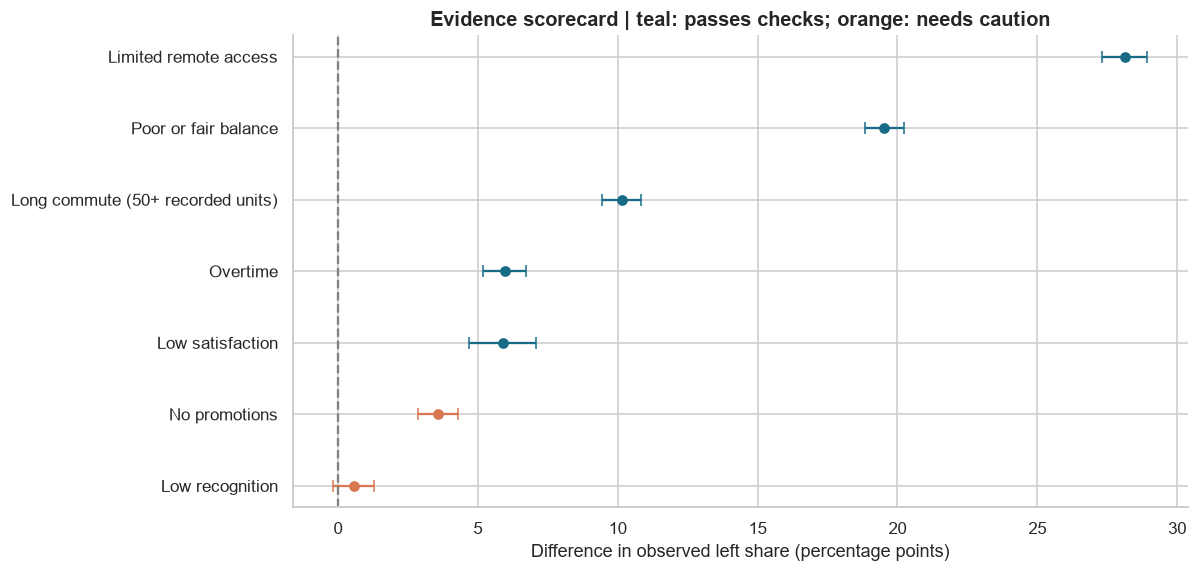

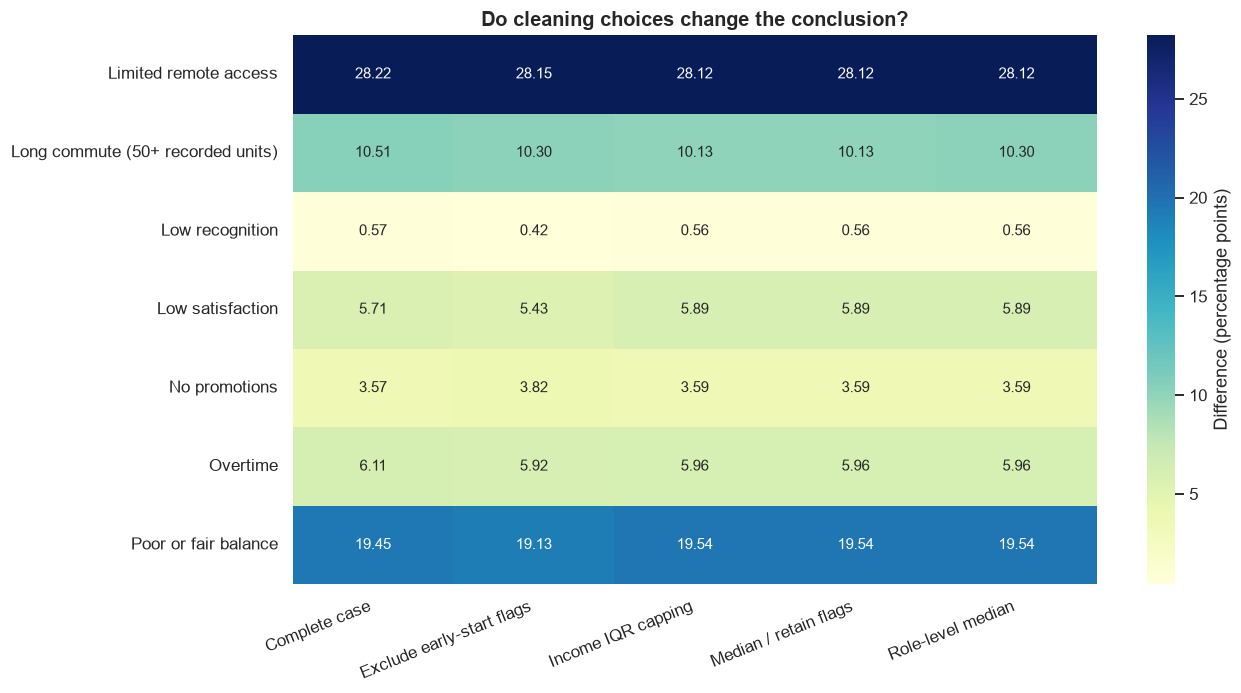

In [10]:
plot = scorecard.sort_values('difference_pp')
fig,ax = plt.subplots(figsize=(11,5.3))
colors = plot.status.map({'Robust descriptive signal':'#176B87','Needs caution':'#DA7652'})
for i,(_,r) in enumerate(plot.iterrows()):
    ax.errorbar(r.difference_pp,i,xerr=[[r.difference_pp-r.ci_low_pp],[r.ci_high_pp-r.difference_pp]],
                fmt='o',color=colors.iloc[i],capsize=4)
ax.set_yticks(range(len(plot)),plot.contrast); ax.axvline(0,color='gray',linestyle='--')
ax.set_xlabel('Difference in observed left share (percentage points)')
ax.set_title('Evidence scorecard | teal: passes checks; orange: needs caution')
finish('04_evidence_scorecard')
pivot = sensitivity.pivot(index='contrast',columns='scenario',values='difference_pp')
fig,ax = plt.subplots(figsize=(12,6.4))
sns.heatmap(pivot,annot=True,fmt='.2f',cmap='YlGnBu',ax=ax,cbar_kws={'label':'Difference (percentage points)'})
ax.set_title('Do cleaning choices change the conclusion?'); ax.set_xlabel(''); ax.set_ylabel('')
ax.set_xticklabels(ax.get_xticklabels(),rotation=22,ha='right')
finish('04_cleaning_sensitivity')

## 8. Compare within job roles and adjust the composition

A pooled gap can reflect different job mixes. First inspect differences separately in each
of the five recorded roles. Then compare the same contrast within role × level strata and
average those differences using the full dataset's stratum proportions. Strata with fewer
than 200 records in either arm are excluded and the covered share is reported. These checks
address only observed role/level composition, not all confounding.

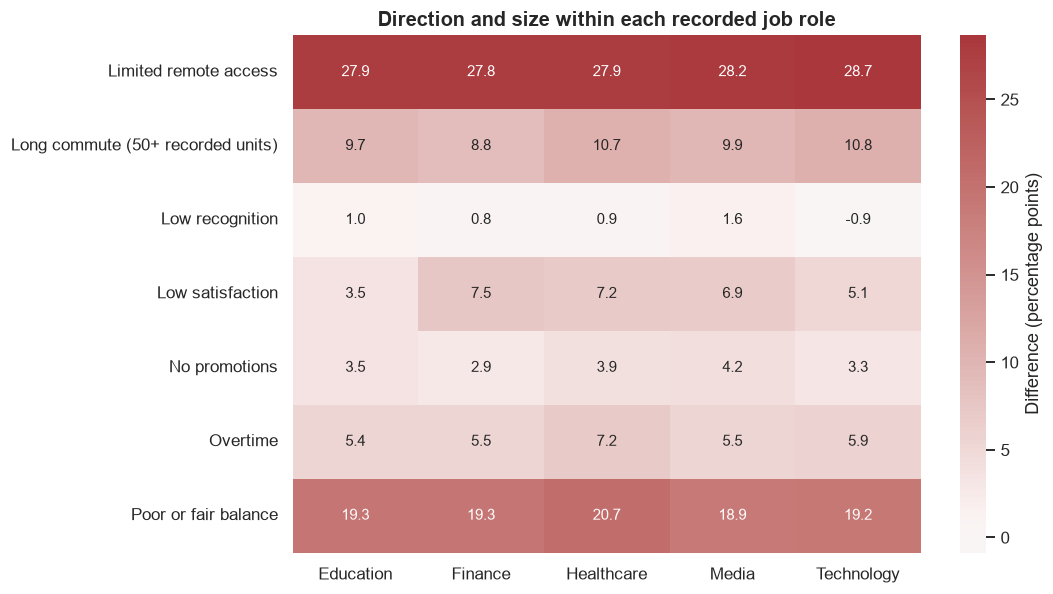

,contrast,difference_pp,standardized_difference_pp,covered_population_pct,status
0,Overtime,5.96,5.84,100.0,Robust descriptive signal
1,Limited remote access,28.12,28.04,100.0,Robust descriptive signal
2,Poor or fair balance,19.54,19.44,100.0,Robust descriptive signal
3,Low satisfaction,5.89,5.83,100.0,Robust descriptive signal
4,Low recognition,0.56,0.65,100.0,Needs caution
5,No promotions,3.59,3.55,100.0,Needs caution
6,Long commute (50+ recorded units),10.13,10.04,100.0,Robust descriptive signal


In [11]:
wp = within_role.pivot(index='contrast',columns='job_role',values='difference_pp')
fig,ax = plt.subplots(figsize=(10,5.5))
sns.heatmap(wp,annot=True,fmt='.1f',cmap='vlag',center=0,ax=ax,cbar_kws={'label':'Difference (percentage points)'})
ax.set_title('Direction and size within each recorded job role'); ax.set_xlabel(''); ax.set_ylabel('')
finish('04_within_role')
display(scorecard[['contrast','difference_pp','standardized_difference_pp','covered_population_pct','status']].round(2))

## 9. Interpretation and next questions

The strongest observed gaps are candidates for follow-up research. They do not identify
causes, predict future resignations or quantify the benefit of a retention programme.
Job satisfaction is non-monotonic, and the recognition comparison illustrates why the
project should be able to say “evidence is weak” instead of producing a confident story
for every variable.

In [12]:
strong = scorecard.loc[scorecard.status.eq('Robust descriptive signal')].sort_values('difference_pp',ascending=False)
weak = scorecard.loc[scorecard.status.eq('Needs caution')]
lines = ['### Findings calculated from this run']
for _,r in strong.iterrows():
    lines.append(f'- **{r.contrast}:** {r.difference_pp:+.2f} percentage points '
                 f'(95% interval {r.ci_low_pp:.2f} to {r.ci_high_pp:.2f}); '
                 f'cleaning swing {r.cleaning_swing_pp:.2f} points.')
for _,r in weak.iterrows():
    lines.append(f'- **{r.contrast}: needs caution.** {r.reason}.')
display(Markdown('\n'.join(lines)))

### Findings calculated from this run
- **Limited remote access:** +28.12 percentage points (95% interval 27.30 to 28.93); cleaning swing 0.10 points.
- **Poor or fair balance:** +19.54 percentage points (95% interval 18.83 to 20.24); cleaning swing 0.40 points.
- **Long commute (50+ recorded units):** +10.13 percentage points (95% interval 9.42 to 10.85); cleaning swing 0.37 points.
- **Overtime:** +5.96 percentage points (95% interval 5.20 to 6.73); cleaning swing 0.19 points.
- **Low satisfaction:** +5.89 percentage points (95% interval 4.70 to 7.09); cleaning swing 0.47 points.
- **Low recognition: needs caution.** interval crosses zero; role inconsistency; below practical threshold; adjusted effect or coverage.
- **No promotions: needs caution.** below practical threshold; adjusted effect or coverage.

## Limitations and Week 4 handoff

- The public dataset's collection process and real-world representativeness remain unverified.
- No observation window means no annual turnover or time-to-resignation estimate.
- Unverified tenure definitions, implausible early starts and unusually patterned relationships
  need source clarification. Cleaning does not make those issues disappear.
- Missingness can be outcome-associated; neither median imputation nor complete cases is
  guaranteed unbiased. Scenario stability is useful but cannot prove correctness.
- Individual observations may not be independent; no company identifier supports clustered inference.
- No model performance, causal savings estimate, individual risk score or intervention claim is made.

**Next work:** verify source definitions; discuss the strongest patterns with the faculty;
extend the evidence comparisons to finer subgroups; fit any later predictive transformations
on training data only; build the narrative dashboard in its scheduled week.

**Week 4 completion:** univariate and bivariate analysis, numeric and categorical summaries,
histograms, bar charts, boxplots, violin plots, scatterplots, heatmaps, confidence-interval plots,
and a reproducible evidence scorecard with explanations.

See `Docs/NOVELTY.md` for the public-product comparison and `Reports/FINDINGS.md` for the concise results.